[Font] 已检测到中文字体: WenQuanYi Micro Hei
Device: cuda
步骤1：TV近端算子（显式先验）演示


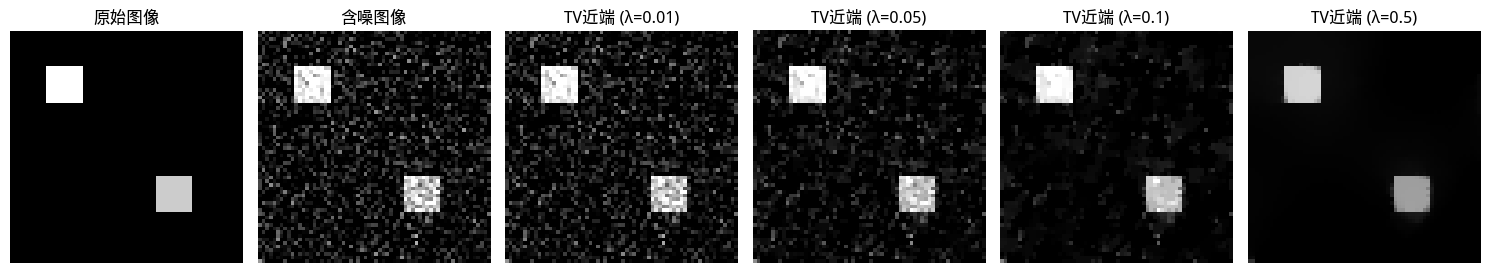

TV近端算子说明：
  λ小（0.01）：近端算子接近输入，TV正则化弱，保留更多噪声
  λ大（0.5）：近端算子趋向于常数，TV正则化强，图像被过度平滑
  适当λ：平衡去噪与保真度

步骤2：显式先验（TV） vs 隐式先验（学习去噪器）对比

实验参数:
  TV-ULA: λ_TV=0.05, δ=0.000006
  PnP-ULA: ε=0.000384, δ=0.000006
  迭代次数: 500

运行TV-ULA...


TV-ULA:   0%|          | 0/500 [00:00<?, ?it/s]


运行PnP-ULA...


PnP-ULA:   0%|          | 0/500 [00:00<?, ?it/s]


步骤3：显式先验（TV）vs 隐式先验（学习去噪器）对比


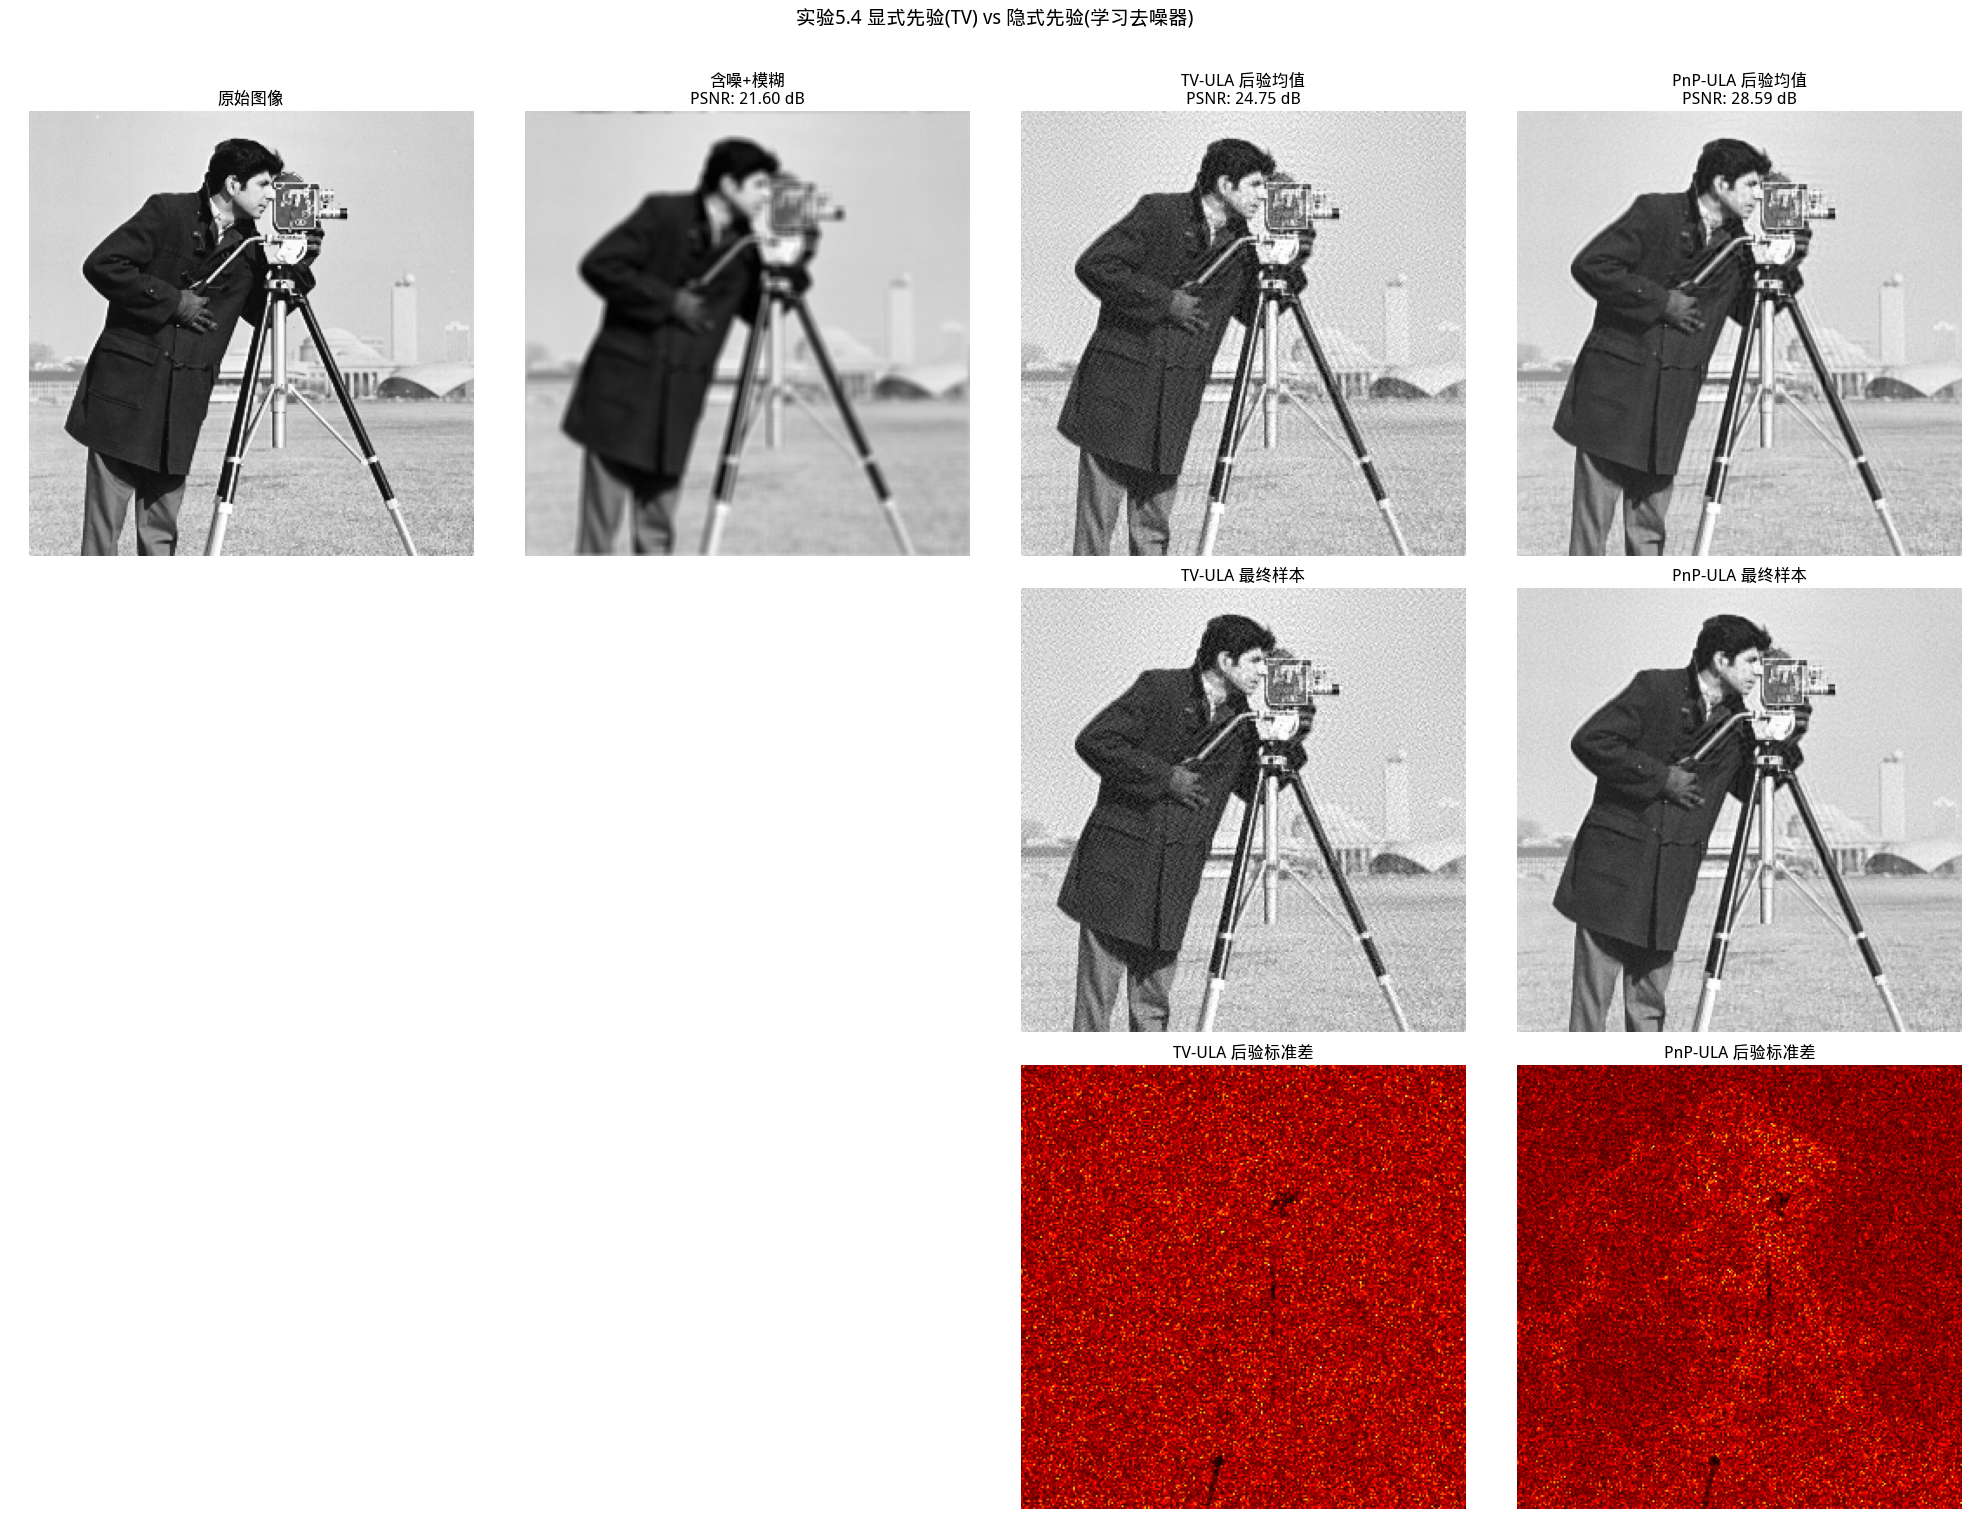


重建质量对比:
  含噪图像:     PSNR = 21.60 dB
  TV-ULA均值:   PSNR = 24.75 dB
  PnP-ULA均值:  PSNR = 28.59 dB

不确定性对比:
  TV-ULA 平均标准差:  0.0179
  PnP-ULA 平均标准差: 0.0146

步骤4：近端算子 vs 去噪器的结构对偶性


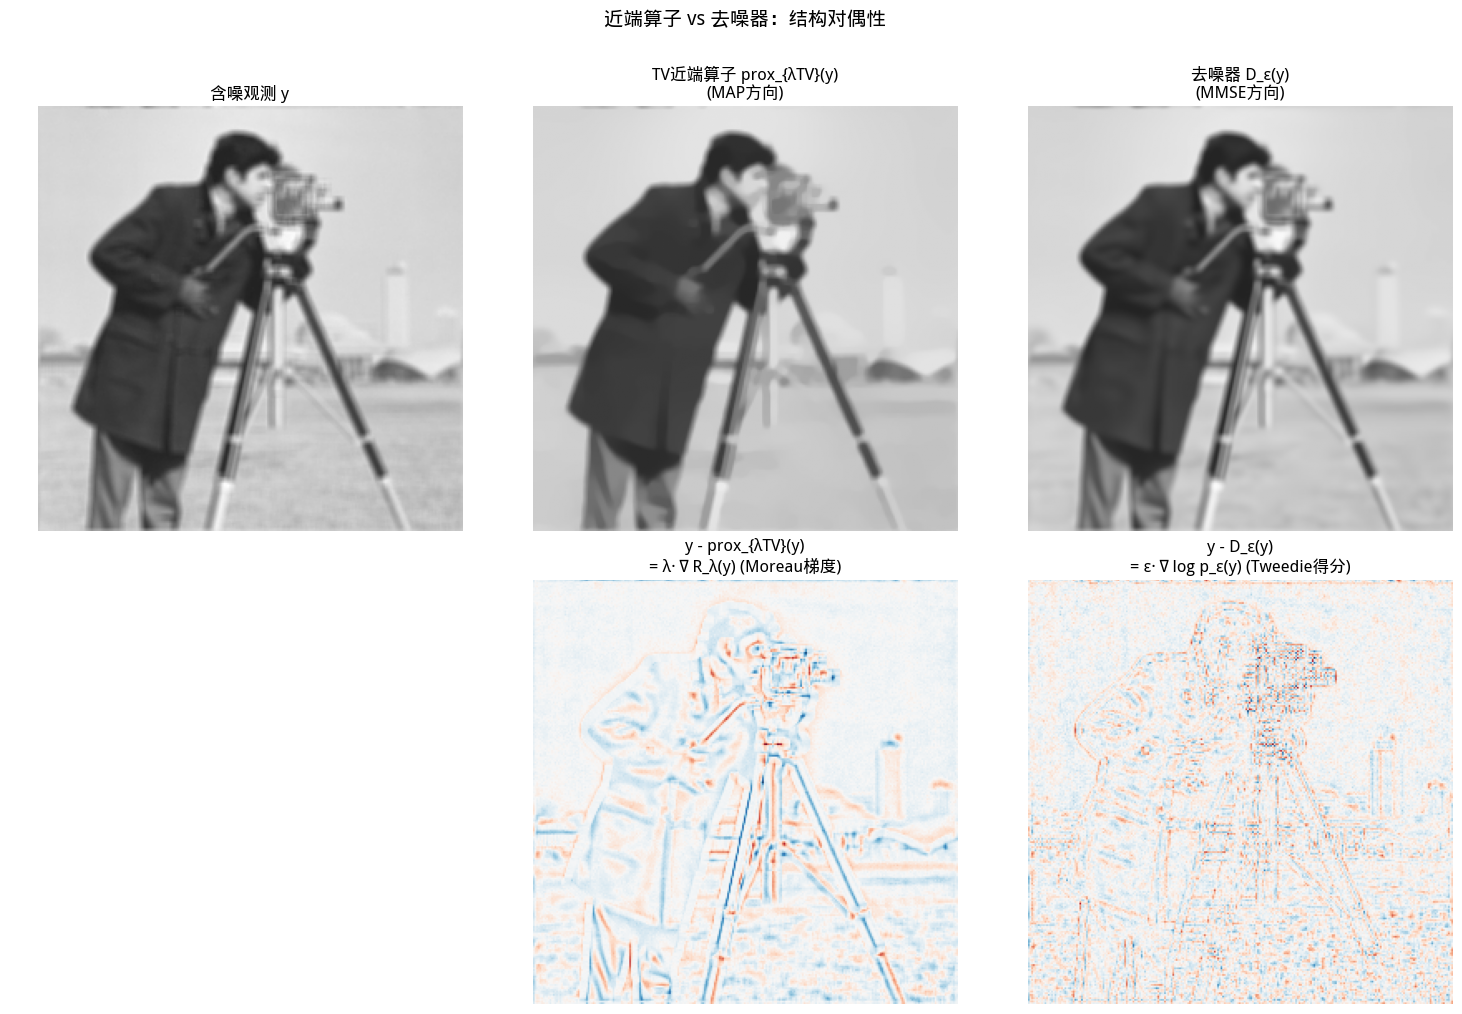


结构对偶性总结：
----------------------------------------------------------------------
性质              Moreau包络（MAP）             软下卷积（MMSE）               
----------------------------------------------------------------------
定义              R_λ(y)=inf{R(x)+||x-y||²/(2λ)} R̄_ε(y)=-log∫exp(...)dx  
算子              prox_{λR}                 D_ε*                     
梯度              ∇R_λ=(y-prox)/λ           ∇R̄_ε=(y-D_ε*)/ε         
一步              prox=y-λ∇R_λ              D_ε*=y-ε∇R̄_ε            
目标              众数（MAP）                   均值（MMSE）                 
温度              T=0（绝对零度）                 T=1（满温度）                 
----------------------------------------------------------------------

实验5.4 总结
1. 近端算子与去噪器的结构对偶：
   数学形式相同：y - c·∇(...)
   近端算子：c=λ，∇是Moreau包络梯度
   去噪器：c=ε，∇是软下卷积梯度
2. 显式先验 vs 隐式先验：
   显式先验（TV）：需要手动选择λ，表达能力有限
   隐式先验（学习去噪器）：自动学习，表达能力强
   学习去噪器通常优于手工先验
3. MAP vs MMSE：
   MAP（近端算子）：输出众数，对应'绝对零度'扩散
   MMSE（去噪器）：输出均值，对应'满温度'扩散
   温度参数T控制从众数到均值的过渡


In [1]:
"""
实验5.4 近端算子 vs 学习去噪器：PnP中的先验替换
对应章节：5.4（MAP与MMSE的结构对偶性）
素材来源：
  - Mathematics.../Teaching Unit 2/labs/lab2_PnP_sol.ipynb（PnP-ULA、去噪器）
  - sampling_tools/chambolle_prox_TV.py（TV近端算子，Chambolle投影算法）
  - 第4章实验4.4 opt_vs_sample.ipynb（MAP vs MMSE对比）

核心思想：
  - 近端算子（MAP方向）：prox_{λR}(y) = argmin_x {R(x) + ||x-y||²/(2λ)}
  - 去噪器（MMSE方向）：D_ε*(y) = E[x|y] = y - ε∇log p_ε(y)
  - 结构对偶：两者形式相同 y - c·∇(...)，但目标不同（众数 vs 均值）

运行前提：
  1. sampling_tools/ 和 Pretrained_models/ 已拷贝到当前目录
  2. 需要GPU和预训练RealSN-DnCNN模型
"""

import math
import torch
import numpy as np
from tqdm.auto import tqdm
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import logging

# ====== 解决中文乱码的核心代码（Windows + Linux 自动适配）======
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")
plt.rcParams['axes.unicode_minus'] = False

import platform
from matplotlib.font_manager import FontManager, FontProperties

def _find_chinese_font():
    """自动检测系统中可用的中文字体，兼容 Windows / Linux"""
    candidates = []
    if platform.system() == 'Windows':
        candidates = ['SimHei', 'Microsoft YaHei', 'KaiTi', 'FangSong']
    else:
        candidates = [
            'WenQuanYi Micro Hei', 'WenQuanYi Zen Hei',
            'Noto Sans CJK SC', 'Noto Sans CJK',
            'Source Han Sans SC', 'AR PL UMing CN',
            'SimHei',
        ]
    fm = FontManager()
    available = set(f.name for f in fm.ttflist)
    for font in candidates:
        if font in available:
            return font
    import os, re
    cjk_patterns = ['cjk', 'wqy', 'noto.*cjk', 'wenquan', 'chinese', 'simhei']
    for f in fm.ttflist:
        name_lower = f.name.lower()
        fname_lower = (os.path.basename(f.fname) if hasattr(f, 'fname') else '').lower()
        for pat in cjk_patterns:
            if re.search(pat, name_lower) or re.search(pat, fname_lower):
                return f.name
    return None

_cn_font = _find_chinese_font()
if _cn_font:
    plt.rcParams['font.sans-serif'] = [_cn_font] + plt.rcParams.get('font.sans-serif', [])
    plt.rcParams['font.family'] = 'sans-serif'
    print(f"[Font] 已检测到中文字体: {_cn_font}")
else:
    print("[Font] 未找到中文字体，中文可能显示为方框")
# ========================================================

np.random.seed(42)
torch.manual_seed(42)

import sys
import os

PARENT_DIR = os.path.dirname(os.path.abspath(''))
if PARENT_DIR not in sys.path:
    sys.path.append(PARENT_DIR)

from sampling_tools import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd()


# ============================================================
# 步骤1：TV近端算子（显式先验）演示
# 使用 sampling_tools/chambolle_prox_TV.py
# ============================================================
print("=" * 60)
print("步骤1：TV近端算子（显式先验）演示")
print("=" * 60)

# 创建测试图像（简单形状）
test_image = np.zeros((64, 64))
test_image[10:20, 10:20] = 1.0  # 正方形
test_image[40:50, 40:50] = 0.8  # 另一个正方形
test_image_t = torch.from_numpy(test_image).float().to(device)

# 添加噪声
noisy_image_t = test_image_t + 0.2 * torch.randn_like(test_image_t)

# 测试不同λ值的TV近端算子
lambda_values = [0.01, 0.05, 0.1, 0.5]

plt.figure(figsize=(15, 4))

plt.subplot(1, len(lambda_values)+2, 1)
plt.imshow(test_image, cmap='gray', vmin=0, vmax=1)
plt.title('原始图像')
plt.axis('off')

plt.subplot(1, len(lambda_values)+2, 2)
plt.imshow(noisy_image_t.cpu().numpy(), cmap='gray', vmin=0, vmax=1)
plt.title('含噪图像')
plt.axis('off')

for i, lambda_ in enumerate(lambda_values):
    result = chambolle_prox_TV(noisy_image_t, device, {'lambda': lambda_, 'maxiter': 200})
    plt.subplot(1, len(lambda_values)+2, i+3)
    plt.imshow(result.cpu().numpy(), cmap='gray', vmin=0, vmax=1)
    plt.title(f'TV近端 (λ={lambda_})')
    plt.axis('off')

plt.tight_layout()
plt.savefig('步骤1_TV近端算子.png', dpi=150)
plt.show()

print("TV近端算子说明：")
print("  λ小（0.01）：近端算子接近输入，TV正则化弱，保留更多噪声")
print("  λ大（0.5）：近端算子趋向于常数，TV正则化强，图像被过度平滑")
print("  适当λ：平衡去噪与保真度")


# ============================================================
# 步骤2：加载图像与去噪器，准备对比实验
# ============================================================
print("\n" + "=" * 60)
print("步骤2：显式先验（TV） vs 隐式先验（学习去噪器）对比")
print("=" * 60)

# 加载图像
im = np.array(Image.open(os.path.join(SCRIPT_DIR, "cman.png")))
x = torch.Tensor(im/255.).to(device)

# 模糊算子
kernel_len = [5,5]
size = [im.shape[0],im.shape[1]]
type_blur = "uniform"
A, AT, AAT_norm = blur_operators(kernel_len, size, type_blur, device)

# 含噪观测
y0 = A(x)
BSNRdb = 40
sigma = torch.linalg.matrix_norm(A(x)-torch.mean(A(x)), ord='fro')/math.sqrt(torch.numel(x)*10**(BSNRdb/10))
y = y0 + sigma * torch.randn_like(x)

# 似然
gradf = lambda x,A,AT : AT(A(x)-y)/sigma**2
L_y = AAT_norm/(sigma**2)

# 去噪器（隐式先验）
L_net = 1.0
model = load_model(os.path.join(SCRIPT_DIR, 'Pretrained_models', 'RealSN_DnCNN_noise5.pth'), device)
denoise = lambda x: (x - model(x[None][None].to(device))[0][0]).detach()

eps = (5/255)**2

projbox = lambda x: torch.clamp(x, min=0, max=1)


# ============================================================
# 步骤2a：TV-ULA（显式TV先验采样）
# 使用 chambolle_prox_TV 提供TV近端，再通过Moreau包络梯度获得TV梯度
# Moreau包络梯度: ∇R_λ(y) = (y - prox_{λR}(y)) / λ
# ============================================================
def tv_ula(y, A, AT, sigma, niter, delta, lambda_tv, device):
    """
    TV-ULA：使用TV先验的ULA采样
    TV梯度通过Moreau包络的梯度获取：
      ∇TV_λ(x) = (x - prox_{λTV}(x)) / λ
    """
    X = y.clone()
    post_sum = torch.zeros_like(X)
    post_sqr = torch.zeros_like(X)

    for k in tqdm(range(niter), desc="TV-ULA"):
        # 似然梯度
        grad_likelihood = gradf(X, A, AT)

        # TV梯度（通过Moreau包络）
        prox_tv = chambolle_prox_TV(X, device, {'lambda': lambda_tv, 'maxiter': 50})
        grad_tv = (X - prox_tv) / lambda_tv  # ∇R_λ(x) = (x - prox) / λ

        # ULA更新
        noise = torch.randn_like(X) * math.sqrt(2 * delta)
        X = X - delta * (grad_likelihood + grad_tv) + noise

        # 投影到[0,1]
        X = projbox(X)

        # 累计统计量
        if k >= niter // 2:
            post_sum += X
            post_sqr += X**2

    n_samples = niter - niter // 2
    post_mean = post_sum / n_samples
    post_var = post_sqr / n_samples - post_mean**2
    post_var = torch.clamp(post_var, min=0)

    return X, post_mean, torch.sqrt(post_var)


# ============================================================
# 步骤2b：PnP-ULA（隐式学习先验采样）
# 使用Tweedie等式从去噪器提取得分函数
# ============================================================
def pnp_ula(y, A, AT, sigma, denoiser, niter, delta, eps, device):
    """
    PnP-ULA：使用学习去噪器的ULA采样
    先验得分通过Tweedie等式获取：
      ∇log p_ε(x) = (D_ε(x) - x) / ε
    """
    X = y.clone()
    post_sum = torch.zeros_like(X)
    post_sqr = torch.zeros_like(X)

    for k in tqdm(range(niter), desc="PnP-ULA"):
        # 似然梯度
        grad_likelihood = gradf(X, A, AT)

        # 先验得分（Tweedie替换）
        score_prior = (denoiser(X) - X) / eps  # ∇log p_ε(x)

        # ULA更新
        noise = torch.randn_like(X) * math.sqrt(2 * delta)
        X = X - delta * (grad_likelihood - score_prior) + noise

        # 投影到[0,1]
        X = projbox(X)

        # 累计统计量
        if k >= niter // 2:
            post_sum += X
            post_sqr += X**2

    n_samples = niter - niter // 2
    post_mean = post_sum / n_samples
    post_var = post_sqr / n_samples - post_mean**2
    post_var = torch.clamp(post_var, min=0)

    return X, post_mean, torch.sqrt(post_var)


# ============================================================
# 运行对比实验
# ============================================================
niter = 500    # 原始10000，此处缩小以便快速演示
lambda_tv = 0.05

# PnP-ULA步长
delta_pnp = 0.99 / (L_net/eps + L_y)

# TV-ULA步长（需要考虑TV梯度的Lipschitz常数，此处简化）
delta_tv = 0.99 / (1.0/lambda_tv + L_y)

print(f"\n实验参数:")
print(f"  TV-ULA: λ_TV={lambda_tv}, δ={delta_tv:.6f}")
print(f"  PnP-ULA: ε={eps:.6f}, δ={delta_pnp:.6f}")
print(f"  迭代次数: {niter}")

print(f"\n运行TV-ULA...")
x_tv_final, x_tv_mean, x_tv_std = tv_ula(y, A, AT, sigma, niter, delta_tv, lambda_tv, device)

print(f"\n运行PnP-ULA...")
x_pnp_final, x_pnp_mean, x_pnp_std = pnp_ula(y, A, AT, sigma, denoise, niter, delta_pnp, eps, device)


# ============================================================
# 步骤3：可视化对比
# ============================================================
print("\n" + "=" * 60)
print("步骤3：显式先验（TV）vs 隐式先验（学习去噪器）对比")
print("=" * 60)

fig, axes = plt.subplots(3, 4, figsize=(20, 15))

# 第1行：原始、含噪
axes[0][0].imshow(im, cmap='gray')
axes[0][0].set_title('原始图像')
axes[0][0].axis('off')

axes[0][1].imshow(y.cpu().numpy(), cmap='gray')
axes[0][1].set_title(f'含噪+模糊\nPSNR: {PSNR(x,y):.2f} dB')
axes[0][1].axis('off')

# TV结果
axes[0][2].imshow(x_tv_mean.cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[0][2].set_title(f'TV-ULA 后验均值\nPSNR: {PSNR(x_tv_mean,x):.2f} dB')
axes[0][2].axis('off')

# PnP结果
axes[0][3].imshow(x_pnp_mean.cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[0][3].set_title(f'PnP-ULA 后验均值\nPSNR: {PSNR(x_pnp_mean,x):.2f} dB')
axes[0][3].axis('off')

# 第2行：最终样本
axes[1][0].axis('off')

axes[1][1].axis('off')

axes[1][2].imshow(x_tv_final.cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[1][2].set_title('TV-ULA 最终样本')
axes[1][2].axis('off')

axes[1][3].imshow(x_pnp_final.cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[1][3].set_title('PnP-ULA 最终样本')
axes[1][3].axis('off')

# 第3行：不确定性
axes[2][0].axis('off')

axes[2][1].axis('off')

axes[2][2].imshow(x_tv_std.cpu().numpy(), cmap='hot')
axes[2][2].set_title('TV-ULA 后验标准差')
axes[2][2].axis('off')

axes[2][3].imshow(x_pnp_std.cpu().numpy(), cmap='hot')
axes[2][3].set_title('PnP-ULA 后验标准差')
axes[2][3].axis('off')

fig.suptitle('实验5.4 显式先验(TV) vs 隐式先验(学习去噪器)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('步骤3_显式vs隐式先验.png', dpi=150, bbox_inches='tight')
plt.show()

# 对比统计
print(f"\n重建质量对比:")
print(f"  含噪图像:     PSNR = {PSNR(x,y):.2f} dB")
print(f"  TV-ULA均值:   PSNR = {PSNR(x_tv_mean,x):.2f} dB")
print(f"  PnP-ULA均值:  PSNR = {PSNR(x_pnp_mean,x):.2f} dB")
print(f"\n不确定性对比:")
print(f"  TV-ULA 平均标准差:  {torch.mean(x_tv_std).item():.4f}")
print(f"  PnP-ULA 平均标准差: {torch.mean(x_pnp_std).item():.4f}")


# ============================================================
# 步骤4：结构对偶性展示
# ============================================================
print("\n" + "=" * 60)
print("步骤4：近端算子 vs 去噪器的结构对偶性")
print("=" * 60)

# 在含噪图像上分别应用TV近端算子和去噪器
y_denoise = y.clone()
sigma_denoise = sigma.item()

# TV近端算子
prox_result = chambolle_prox_TV(y_denoise, device, {'lambda': 0.05, 'maxiter': 200})

# 学习去噪器
denoise_result = denoise(y_denoise)

# 可视化对比
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0][0].imshow(y.cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[0][0].set_title('含噪观测 y')
axes[0][0].axis('off')

axes[0][1].imshow(prox_result.cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[0][1].set_title('TV近端算子 prox_{λTV}(y)\n(MAP方向)')
axes[0][1].axis('off')

axes[0][2].imshow(denoise_result.cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[0][2].set_title('去噪器 D_ε(y)\n(MMSE方向)')
axes[0][2].axis('off')

# 残差对比：y - prox vs y - denoiser
residual_prox = y - prox_result  # λ·∇R_λ(y) (Moreau包络梯度方向)
residual_denoise = y - denoise_result  # ε·∇log p_ε(y) (Tweedie得分方向)

axes[1][0].axis('off')

axes[1][1].imshow(residual_prox.cpu().numpy(), cmap='RdBu_r')
axes[1][1].set_title('y - prox_{λTV}(y)\n= λ·∇R_λ(y) (Moreau梯度)')
axes[1][1].axis('off')

axes[1][2].imshow(residual_denoise.cpu().numpy(), cmap='RdBu_r')
axes[1][2].set_title('y - D_ε(y)\n= ε·∇log p_ε(y) (Tweedie得分)')
axes[1][2].axis('off')

fig.suptitle('近端算子 vs 去噪器：结构对偶性', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('步骤4_结构对偶性.png', dpi=150, bbox_inches='tight')
plt.show()


# ============================================================
# 结构对偶性总结表
# ============================================================
print("\n结构对偶性总结：")
print("-" * 70)
print(f"{'性质':<15} {'Moreau包络（MAP）':<25} {'软下卷积（MMSE）':<25}")
print("-" * 70)
print(f"{'定义':<15} {'R_λ(y)=inf{R(x)+||x-y||²/(2λ)}':<25} {'R̄_ε(y)=-log∫exp(...)dx':<25}")
print(f"{'算子':<15} {'prox_{λR}':<25} {'D_ε*':<25}")
print(f"{'梯度':<15} {'∇R_λ=(y-prox)/λ':<25} {'∇R̄_ε=(y-D_ε*)/ε':<25}")
print(f"{'一步':<15} {'prox=y-λ∇R_λ':<25} {'D_ε*=y-ε∇R̄_ε':<25}")
print(f"{'目标':<15} {'众数（MAP）':<25} {'均值（MMSE）':<25}")
print(f"{'温度':<15} {'T=0（绝对零度）':<25} {'T=1（满温度）':<25}")
print("-" * 70)


# ============================================================
# 实验总结
# ============================================================
print("\n" + "=" * 60)
print("实验5.4 总结")
print("=" * 60)
print("1. 近端算子与去噪器的结构对偶：")
print("   数学形式相同：y - c·∇(...)")
print("   近端算子：c=λ，∇是Moreau包络梯度")
print("   去噪器：c=ε，∇是软下卷积梯度")
print("2. 显式先验 vs 隐式先验：")
print("   显式先验（TV）：需要手动选择λ，表达能力有限")
print("   隐式先验（学习去噪器）：自动学习，表达能力强")
print("   学习去噪器通常优于手工先验")
print("3. MAP vs MMSE：")
print("   MAP（近端算子）：输出众数，对应'绝对零度'扩散")
print("   MMSE（去噪器）：输出均值，对应'满温度'扩散")
print("   温度参数T控制从众数到均值的过渡")
